github에 공개된 정보 활용

In [ ]:
#코랩 탭의 파일구조 내에서 위에서 복제한 실습 자료가 있는 폴더로 이동한다.
%cd /content/logisticregression
# 나이(Age)와 급여(Salary)에 따른 
# 상품 구매 여부(Purchased)(구매했는가 1 or 구매하지 않았는가? 0)
# 를 판단하기 위한 정형데이터와 이진 분류 모델을 실습한다.


## 런타임을 전부 실행하고 
## 왼쪽 하단의 폴더 아이콘을 클릭하여  /content/logisticregression 폴더 경로에 Social_Network_Ads.csv 파일을 더블클릭해보자. 
## 오른쪽에 데이터(소셜네트워크관련)를 확인할 수 있다.
## 행과 열에 어떤 카테고리들이 특징벡터로, 실제값으로 각각 활용되는지 확인해보자.

# 로지스틱 회귀 (logistic regression) (실습)

### [1] 실습 진행 관련 설명
로지스틱 회귀에 대한 실습을 진행하고자 한다. 실습은 크게 두가지로 구성되어 있다.

- sklearn 라이브러리를 이용한 방법
- 직접 함수를 구현하는 방법

처음에는 sklearn 라이브러리를 이용한 방법을 실습하고 그 이후에 직접 함수를 구현하여 실습을 진행한다.

## [2] 코드 구현의 흐름


- (1) (데이터 측면) 데이터 불러오기 및 특성 스케일링

- (2) (데이터 측면) 데이터에서 훈련데이터와 테스트 데이터로 구분하고

- (3) (모델 측면) sklearn 라이브러리를 이용하여 로지스틱 회귀 모델 불러오기. 또는 직접 함수 구현하기 (로지스틱회귀 모델 정의).

- (4) (학습 과정) sklearn 라이브러리를 이용하여 모델 학습하기. 또는 직접 구현하기 (Loss 정의 & Sigmoid).

- (5) (성능 평가) 테스트 데이터를 이용하여 학습된 모델에 대한 성능 평가하기. (정확도)

이번 실습에서 활용한 데이터는 "User ID", "Gender", "Age", "EstimatedSalary", "Purchased"의 컬럼으로 구성되어 있으며, 학습 과정에서는 "Age"와 "EstimatedSalary"를 특징으로 활용(X = dataset.iloc[:, [2, 3]].values)

종속변수에 해당하는 값은 "Purchased" 컬럼(y = dataset.iloc[:, 4].values)

(참고)

**Feature scaling**

이번 실습에서는 주어진 데이터의 값을 변환하는 과정이 포함되어 있다. 

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

라는 2줄의 코드를 보면 (1) sklearn의 preprocessing 패키지로부터 "StandardScaler"를 불러온 후 ("from sklearn.preprocessing import StandardScaler") (2) StandardScaler()에 "sc"라는 이름을 부여하여 사용한다("sc = StandardScaler()").

StandardScaler는 "x"라는 값을 "z"라는 값으로 변환하는데 변환 공식은 z=(x-u)/s (여기서 "u"는 학습데이터 관측값의 평균, "s"는 학습데이터 관측값의 표준 편차)으로 표현된다.인공지능입문에서는 StandardScaler를 비롯한 feature scaling을 하면 학습에 큰 도움을 준다고 이해하여도 충분하다.

**주의**

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

위의 두 줄의 코드를 살펴보면 X_train에 대해서는 sc의 "fit_transform()"을 사용하고 X_test에 대해서는 sc의 "transform()"을 사용한다. "fit_transform()"을 먼저 X_train에 적용하면 X_train의 평균과 분산값을 확보한 후 특징 값을 변화시킨다. "transform()"은 "fit_transform()"에서 확보한 X_train의 평균과 분산값을 X_test에 적용하여 특징 값을 변화시킨다. 훈련데이터와 테스트데이터에 대하여 feature scaling을 적용할 때는 동일한 인자를 적용하여 특징 값을 변화시키도록 주의하자.

## (첫번째 실습) sklearn 라이브러리를 이용한 방법 




**모델 학습과 테스트**

from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state = 0)

classifier.fit(X_train, y_train)

위 세줄의 코드에서는 (1) LogisticRegression 모델을 불러온 후("from sklearn.linear_model import LogisticRegression") (2) 우리가 사용할 LogisticRegression 모델에 "classifier"라는 이름을 부여하고("classifier = LogisticRegression(random_state = 1)") (3) 모델을 학습시킨다("classifier.fit(X_train, y_train)")

sklearn의 LogisticRegression을 사용할 때는 다양한 인자를 함께 설정할 수 있는데(인자의 자세한 설명은 [표준문](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)서를 참고), random_state의 효과에 대해서는 표준문서의 설명을 알아보자.

학습이 끝난 모델의 테스트는 " predict()"함수를 사용한다(y_pred = classifier.predict(X_test)).

**분류의 성능평가지표**

분류 작업을 수행하는 모델의 성능을 평가할 때는 다양한 성능측도를 사용하는데 우선은 Accuracy와 F1 score를 알아보자. 

1. Accuracy라는 평가지표는 테스트 데이터에서 모델이 클래스 레이블을 정확하게 예측한 비율을 표시한다.

2. Precision은 Positive와 Negative라는 두 개의 클래스에 대한 이진 분류 문제에서 모델이 Positive클래스에 속한다고 예측한 관측값 중 실제로 Positive 클래스에  속한 관측값의 비율을 표시한다.

3. Recall은 Positive 클래스에 속하는 관측값 중 모델이 Positive라고 예측한 관측값의 비율을 표시한다.

4. F1 score는 2*(Precision * Recall)/(Precision + Recall)을 의미

In [5]:
# 로지스틱 회귀(Logistic Regression)
# 필수 라이브러리 가져오기 : 함수와 기능들의 묶음.
import numpy as np   # 넘파이, 계산, 수학을 위한 라이브러리
import matplotlib.pyplot as plt  # 맷플롯립, 시각화를 위한 라이브러리
import pandas as pd  # 판다스, 데이터를 불러오기위한 라이브러리
import sklearn  # 사이킷런, 회귀 분류 등 인공지능 모델을 간단한 함수만으로 구현 가능한 라이브러리

In [6]:

# (1) (데이터 측면) 데이터 불러오기 (Importing the datas) 및 스케일링
dataset = pd.read_csv('./data/Social_Network_Ads.csv')   
## 데이터셋을 판다스의 read_csv 함수로 불러온다. 
## csv 란? 테이블이나 스프레드시트로 데이터를 설명하는 정형데이터 표현 형식
X = dataset.iloc[:, [2, 3]].values  
# iloc은 넘파이의 인덱싱/슬라이싱 기능과 동일하다. [행, 열] 개념에 유의  
y = dataset.iloc[:, 4].values 
## 2번 Age 나이, 3번 Salary 급여 // 4번은 Purchased 상품구매여부 의 열(column) 인덱스를 불러오는 표현이다.



In [17]:
# 특성 스케일링 : 스케일링을 통해 데이터 분포를 정규화 할 수 있다.
 ## https://wikidocs.net/87252 사이트에서 스케일링을 통해 데이터 분포가 어떻게 변화하는지 확인하라.
 ## 정규화를 통해서 데이터로부터 도출되는 확률분포의 추정능력이 향상되고, 연산량도 줄어들게 되어 많은 이점이 있다.
from sklearn.preprocessing import StandardScaler 
sc = StandardScaler()
X = sc.fit_transform(X)
 ##. 학습데이터에 대해서 "fit_transform()" 평균과 분산을 표준정규분포 형태로 바꿔준다.
 ##. https://deepinsight.tistory.com/165
 ##. 실제로 많이 사용되지만 데이터의 분산으로 인한 편향을 없애주는 좋은 기능이다 정도로 알아두자.
 
 ## feature scaling 전 데이터에 대해서도 정확도를 측정해봐야한다


In [8]:
# (2) (데이터 측면) 훈련 데이터셋과 테스트 데이터셋을 구분하기
from sklearn.model_selection import train_test_split
 ##. split은 쪼개다.라는 뜻. 사이킷런으로부터 학습데이터와 검증데이터를 나눈다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)
 ##. test_size=0.25 // 75%, 25% 비율로 학습용데이터와 검증용데이터를 나눈다. 즉, 300개 / 100개
 ##. random_state // 회귀에서는 0이었지만 난수를 1로 설정함으로써 데이터의 순서에의한 편향성을 제거하도록 랜덤하게 데이터 순서를 섞어서 입력으로 사용한다.


In [9]:
# (3) (모델 측면) 로지스틱 회귀 모델 불러오기
 ##. 로지스틱 회귀는 사이킷런을 활용할때 모델의 선형판별함수, 로지스틱함수, 예측, 이진분류 손실함수와 경사하강법까지 
 ##. 전부 LogisticRegression.fit() // 함수 하나로 모든 프로세스가 진행가능하다.(매우 편리)(두번째 실습 직접구현과 비교해보라.)

from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()

In [10]:
# (4) (학습 과정) 모델 학습 하기
# 학습과정에서는 Train 데이터만! 사용된다.
classifier.fit(X_train, y_train)

print(classifier.coef_)
print(classifier.intercept_)
 ## coef_ : 최종 업데이트가 완료된 가중치 w1, w2 를 의미한다.
 ## intercept_ : 최종 업데이트가 완료된 가중치 w0 를 의미한다.

[[1.97070413 1.07127108]]
[-1.04821888]


In [11]:
# (5) (성능 평가) 학습된 모델을 대상으로 테스트 데이터로 평가하기. (Predicting the Test set results)
# 성능평가 과정에서는 Test 데이터만! 사용된다.
# 테스트 데이터에 대하여 예측값 확보
y_pred = classifier.predict(X_test)
 ## 이번엔 테스트 데이터에 대해서 프로세스를 진행하는데 이때는 predict()함수가 손실과 경사하강법을 제외하고
 ## 모델의 예측값만 계산해준다.


In [12]:
#분류 성능 측도
print(sklearn.metrics.accuracy_score(y_test, y_pred))
 ## Accuracy 우리가 통상 이해하는 모델의 신뢰도 (성공의 확률/실패의 확률)을 의미한다.
print(sklearn.metrics.f1_score(y_test, y_pred))
 ## F1 score는 accuracy와 함께 모델의 신뢰도를 측정하는 수치(점수)의 종류 중 하나이다. 
 ## 학습데이터 만으로 분류 확률이 잘 나온다고해서 새로운 데이터가 무수히 등장할 산업현장에 AI모델을 투입할 수는 없지 않은가! 따라서 신뢰도 검증이 필요하다.
 ## https://www.linkedin.com/pulse/precision-recall-f1-score-object-detection-back-ml-basics-felix
 ## 더 알고 싶다면, 위 사이트의 내용을 참고해보세요.

0.86
0.78125


- 경고무시

프로그램을 작성할 때 에러 메시지와 경고메시지는 매우 중요한 역할을 하지만, 경고 메시지의 경우 출력 화면에 부가 정보를 대량으로 표시하여 결과 확인을 어렵게 하기도 한다. 이런 경우 파이썬의 경고 메시지를 무시하도록 설정할 수 있는데, 경고 메시지를 무시하고 싶으면 다음 코드를 추가한다.

import warnings

warnings.filterwarnings('ignore')

In [13]:
import warnings
warnings.filterwarnings('ignore')

**결과 시각화**

코드에서는 ListedColormap과 등고선플롯(contourf)을 이용하여 결과를 가시화하고 있다. 인공지능입문에서 소개되는 matplotlib의 다양한 기능을 활용하여 결과를 직관적으로 표시할 수 있도록 화면에 그려지는 결과를 잘 살펴보자.

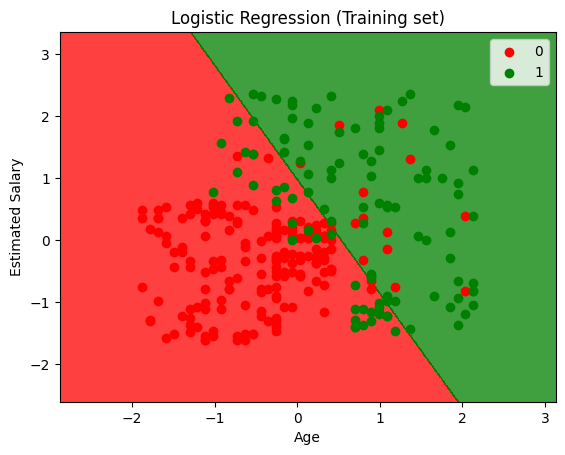

In [ ]:
### 훈련 결과 가시화
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
  ## 맷플롯립(시각화 도구) 함수에 학습데이터를 입력시킨다.

#격자 형태 그리드
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
  ## 메쉬그리드는 그래프의 밑그림을 그려준다.

#등치선 표현 함수
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape), alpha = 0.75, cmap = ListedColormap(('red', 'green')))

  ## 컨투어에프 함수는 초평면, 선형판별함수를 그려준다.
  ###ravel : 2D --> 1D로 펼치기
  
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
  ## xlim, ylim --> x, y 값의 최대, 최소 표현 범주를 정의한다.
  
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
  ## 빨강, 초록으로 특징벡터 점들의 클래스 범주를 나누어준다. 

plt.title('Logistic Regression (Training set)') # 그래프 제목
plt.xlabel('Age') # x축 라벨
plt.ylabel('Estimated Salary') # y축 라벨
plt.legend() # 범례
plt.show() # 이모든걸 아래 출력하시오.

- 학습데이터로 학습된 결과 0일 확률은 붉은 색,
 1일 확률은 초록 색으로 나타냈으며 초평면 대각선이 이러한 범주를 나누고, 서로다른 색상으로 드러나는 점들은 전부 모델이 예측에 실패한 데이터들이다.

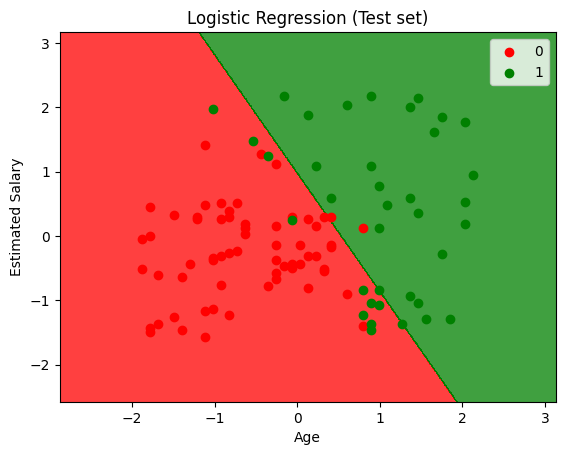

In [15]:
### 테스트 결과 시각화
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
 ## 이번엔 테스트, 즉 검증 데이터로 시각화를 해보자 위에서 사용한 맷플롯립코드와 동일하다.
 
#격자 형태 그리드
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
#등치선 표현 함수
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## (두번째 실습) 직접구현


**구현과정에서 사용된 함수의 설명**

아래의 코드셀에서는 np.mean(), np.log(), np.exp(), np.dot()와 같은 함수들이 사용된다.np.mean(), np.log(), np.exp()는 이름만으로 기능을 유추할 수 있을 것인데, 아래의 코드셀의 실행 결과를 살펴보자. 
1. np.mean()은 입력으로 리스트가 주어졌을 때 리스트를 구성하는 원소들의 평균값을 반환한다.
2. np.log()에 대해서는 크게 두 가지를 주의해야 한다. (2-1) numpy의 log()는 자연상수(e)를 밑으로 하는 로그를 계산한 것을 반환한다. 즉 numpy의 log(x)는 ln(x)와 동일한 기능을 수행한다. (2-2) numpy의 log()는 리스트를 인자로 받을 수 있다. 리스트가 인자로 주어지면 리스트를 구성하는 개별 원소에 대한 자연 로그 값을 반환한다.
3. np.exp()는 지수함수(exponential function), 그 중에서도 e^(x) 형태를 계산한다. np.log()와 마찬가지로 리스트를 인자로 받을 수 있다.
4. np.dot()은 좀 더 자세히 살펴보도록 하자.

**np.dot()의 동작**

아래 코드셀에서 

1. "- 1번 상황 : 벡터와 벡터"은 x = [2, 3, 4]와 w = [1, 2, 3]의 내적 연산 결과를 반환한다.
2. "- 2번 상황 : 행렬과 벡터"은 x2 = np.array([[1,2], [3, 4], [5, 6]])와 w = [1, 2, 3]에 대하여 np.dot(x2.T, w)의 연산을 수행한다. x2.T는 행렬에 대한 전치연산이므로 (3,2)의 모양을 가지고 있던 x2가 (2, 3) 모양으로 변한다. np.dot(x2.T, w)의 연산 결과인 [22 28]은 (2, 3) 형태인 x2.T와 (3, )형태인 w에 대하여 행렬 곱 연산을 수행한 결과이므로 (2, )형태의 결과물이 출력된다.보다 자세하게 설명하면 [1, 3, 5]벡터와 [1, 2, 3] 벡터의 내적 연산 결과인 22, [2, 4, 6]벡터와 [1, 2, 3]벡터의 내적 연산 결과인 28이 각각 출력되었다.
3. "- 3번 상황 : 행렬과 행렬"은 (2, 3) 모양인 x2.T와 (3, 2) 모양인 w2에 대하여 행렬곱을 수행한 상황이다. 따라서 (2, 2) 모양의 결과가 계산되었다. 보다 자세하게 설명하면 [1, 3, 5]벡터와 [1, 2, 2] 벡터의 내적 연산 결과인 17, [1, 3, 5]벡터와 [-1, 0, 3] 벡터의 내적 연산 결과인 14, [2, 4, 6]벡터와 [1, 2, 2]벡터의 내적 연산 결과인 22, [2, 4, 6]벡터와 [-1, 0, 3] 벡터의 내적 연산 결과인 16이 출력되었다

**gradients 함수의 구현**

```
def gradients(X, y, y_hat):
    dw = np.dot(X.T, (y-y_hat))
    return dw
```
gradients 함수의 구현을 자세히 살펴보자. train()함수 내부에서 gradients함수가 호출되는 아래의 코드에서 gradients함수에게 인자로 주어지는 xb, yb, y_hat은 각각 (100,2), (100,1), (100,1)의 모양을 하고 있다. 

```
dw = gradients(xb, yb, y_hat)
```

gradients 함수의 함수 몸체에서는 

```
np.dot(X.T, (y-y_hat))
```
상기 형태의 연산을 수행하고 있는데, X.T는 (2, 100) 모양의 행렬이고, (y-y_hat)은 (100, 1) 모양의 행렬(혹은 벡터)이므로 np.dot(X.T, (y-y_hat))은 행렬과 벡터를 곱한 (2, 1)모양의 결과물을 반환한다.이 결과물은 "N인공지능입문_로지스틱회귀p2.pdf"라는 이름의 강의자료에서 13 슬라이드나 16번 슬라이드의 편미분 수식 중 합에 해당하는 부분만을 구현한 것이다(주의 y_hat은 "y_hat = sigmoid(np.dot(xb, w)"의 코드로 계산됨).

-정리 : "np.dot(X.T, (y-y_hat))"의 간단한 표현으로 
16번 슬라이드의 summation에 해당하는 복잡한 연산이 표현되었음에 주의하자. 



**실습 코드에서 주의할 점**

```
def loss(y, y_hat):
    loss = np.mean(y*(np.log(y_hat)) + (1-y)*np.log(1-y_hat))
    return -loss
```
상기 코드로 표현된 loss함수의 구현을 보면 np.mean()을 수행하여 Cross entropy의 평균을 계산함을 알 수 있다.

그러나 경사하강법을 적용하여 인자를 갱신하는 다음의 코드를 보면

```
y_hat = sigmoid(np.dot(xb, w) )
            dw = gradients(xb, yb, y_hat)
            w += lr*dw
```
gradients()함수의 반환값에 학습율(lr)을 곱한 값을 w에 더하는 것을 알 수 있다. 

즉, 실습 코드에서서는 값이 줄어드는 것을 보여주기 위하여 loss 함수에서는 바이너리 크로스 엔트로피의 평균을 계산하고 있으나, 인자를 갱신하는 과정에서는 log likelihood를 사용하는 다소 복잡한 구현을 택하고 있다. 





In [ ]:
x = [2, 3, 4]
print("=== numpy의 mean() ====")
print(np.mean(x))
print("=== numpy의 log() ====")
print(np.log(x))
print("=== numpy의 exp() ====")
print(np.exp(x))
print("\n**** numpy의 dot() ****")

print("- 1번 상황 : 벡터와 벡터")
w= [1, 2, 3]
print(np.dot(np.array(x).T, w)) ## 1*2 + 2*3 + 3*4 = 20
print("- 2번 상황 : 행렬과 벡터")
x2 = np.array([[1,2], [3, 4], [5, 6]]) 
print(np.dot(x2.T, w)) ## (2by3) * (3,) --> (2,)
print("- 3번 상황 : 행렬과 행렬")
w2 = [[1, -1], [2, 0], [2,3]]
print(np.dot(x2.T, w2)) ##(2by3) * (3by2) --> (2by2)

=== numpy의 mean() ====
3.0
=== numpy의 log() ====
[0.69314718 1.09861229 1.38629436]
=== numpy의 exp() ====
[ 7.3890561  20.08553692 54.59815003]

**** numpy의 dot() ****
- 1번 상황 : 벡터와 벡터
20
- 2번 상황 : 행렬과 벡터
[22 28]
- 3번 상황 : 행렬과 행렬
[[17 14]
 [22 16]]


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

In [20]:
# (1) (데이터 측면) 데이터 불러오기 (Importing the datas) 및 스케일링
dataset = pd.read_csv('./Data/Social_Network_Ads.csv')
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

In [21]:
# 특성 스케일링
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)
# StandardScaler의 효과를 이해할 수 있도록 
# X_train = sc.fit_transform(X_train),X_test = sc.transform(X_test)를 주석 처리한 후 결과를 비교해보자. 
# 주의 : fit_trainsform과 transform의 효과를 비교하려면 현재 구현과 틀리게 train_test_split을 먼저 실행한 후
# StandardScaler를 실행해야 한다.

In [22]:
# (2) (데이터 측면) 훈련 데이터셋과 테스트 데이터셋을 구분하기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 1)

print(X_train.shape)

(300, 2)


In [25]:
# (3) (모델 측면) 로지스틱 회귀 모델 불러오기

 ## 아래 코드는 위의 사이킷런 라이브러리에서 fit, predict 함수들로 4줄만에 표현 가능한 인공지능 분류 모델의 학습과 검증 절차를 세분화하여 파이썬코드로 하나하나 자세히 구현한 내용이다.
# 시그모이드 함수의 구현
def sigmoid(x):
    return 1.0/(1 + np.exp(-x))
  ## exp(x)가 지수함수(e^(x))와 동일한 표현임에 유의의. 
  
# 로지스틱 회귀의 손실함수형태와 코드를 잘 비교해보자.
# 질문 : loss(y, y_hat) 함수에서 계산하는 값은 무엇인가?
### Ans) Binary Cross Entropy 를 계산한다
## y=0, y=1일때 두가지 상황을 한꺼번에 계산할 수 있는 베르누이 공식으로부터 유도된 바이너리 크로스 엔트로피 손실함수이다. BCE_Loss

# 아래 코드에서 y_hat은 y_hat = sigmoid(np.dot(xb, w) )로 계산되는 값으로
# C1클래스에 대한 사후확률을 아래 코드에서는 y_hat으로 표현했음을 알 수 있다.
def loss(y, y_hat):
    loss = np.mean(y*(np.log(y_hat)) + (1-y)*np.log(1-y_hat))
    ## np.mean이 (N개의 각 데이터의 계산의 총합/N)을 나타낸다.
    return -loss
    ## 왜 (-)음수인가? 우도(y_hat)을 증가시키려면, -ln 마이너스 자연로그를 감소시켜야한다.

# 로지스틱 회귀의 인자 갱신식과 잘 비교해보자.
def gradients(X, y, y_hat):
    dw = np.dot(X.T, (y-y_hat))
    return dw
    ## 강의자료료의 그라디언트(미분, 기울기) 전개식을 비교해보라. x와 오차(y-y_hat)간의 곱으로 나타낸다.


In [26]:
# (4) (학습 과정) 모델 학습 하기
# 학습과정에서는 Train 데이터만! 사용된다.
def train(X_train, y_train, bs, epochs, lr):
    m, n = X_train.shape
    w = np.zeros((n,1))
    y_train = y_train.reshape(m,1)
    losses = []
    train_acc = []
    test_acc = []
    ## 먼저 위와 같이 학습을 위해 필요한 변수들을 정의한다.
    # epochs에서 지정된 값만큼 반복.
    for epoch in range(epochs):
        # 아래 for loop는 어떤 동작을 하는지 설명을 시도해보자
        # bs의 값과 m의 값을 파악한 후 xb, yb를 유추하면  
        # 아래 for loop의 동작을 이해할 수 있다.
        for i in range((m-1)//bs + 1): # "//"연산자는 파이썬에서 어떤 기능을 하는가? 
            start_i = i*bs
            end_i = start_i + bs
            xb = X_train[start_i:end_i]
            yb = y_train[start_i:end_i]
            y_hat = sigmoid(np.dot(xb, w) )
            dw = gradients(xb, yb, y_hat)
            w += lr*dw   # 인자 갱신식에서 w = w + lr*dw로 구현되었음에 유의하자
# 반복문 for문의 안쪽이 있는 함수는 무엇이고 바깥쪽에 있는 함수는 무엇인지에 유의하자.

        l = loss(y_train, sigmoid(np.dot(X_train, w)))
        tr_acc = accuracy_score(y_train, predict(X_train, w))
        te_acc = accuracy_score(y_test, predict(X_test, w))
        losses.append(l)
        train_acc.append(tr_acc)
        test_acc.append(te_acc)
        if epoch %10 == 0:
            ## 반복횟수 에포크 10을 나누었을때 나머지가 0인 숫자, 즉 10번째마다 if문이 아래 print()를 출력한다.
          print("loss = ", l)
          print("training accuracy ", tr_acc)
          print("testing accuracy ", te_acc)
        
    return w,losses, train_acc, test_acc
    ## 리턴으로 필요한 값을 전달한다.


In [27]:
# (5) (성능 평가) 학습된 모델을 대상으로 테스트 데이터로 평가하기. (Predicting the Test set results)
# 성능평가 과정에서는 Test 데이터만! 사용된다.
# 테스트 데이터에 대하여 예측값 확보
# 이번 예제에서는 Train 함수 안에서 사용되었음에 주의
def predict(X, w):
    
    # 예측값 계산
    preds = sigmoid(np.dot(X, w))
    
    pred_class = []
    # 이진 분류에서 사후 확률에 기반한 결정 규칙 구현
    pred_class = [1 if i > 0.5 else 0 for i in preds]
    ## .sigmoid(np.dot(X, w))의 계산결과가 1/2이상이면 1번 클래스, 그렇지 않으면 0번 클래스로 간주

    return np.array(pred_class)

In [28]:
# X_train의 shape을 확인해보면 (300,2)이다. 
w, l, train_acc, test_acc = train(X_train, y_train, bs=100, epochs=100, lr=0.1/len(X_train))
## 바이어스, 반복횟수, 알파(학습률) 전부다 직접 정의해준다. 
## 이렇게 사용자가 직접 바꾸는 초매개변수를 하이퍼파라미터라고 부른다.
y_pred = predict(X_test, w)

loss =  0.6816725761443988
training accuracy  0.8066666666666666
testing accuracy  0.83
loss =  0.5957731268246116
training accuracy  0.8066666666666666
testing accuracy  0.83
loss =  0.5443613965734062
training accuracy  0.81
testing accuracy  0.83
loss =  0.5114817898149377
training accuracy  0.8066666666666666
testing accuracy  0.83
loss =  0.48912463409092044
training accuracy  0.8033333333333333
testing accuracy  0.83
loss =  0.4731543137556072
training accuracy  0.8033333333333333
testing accuracy  0.83
loss =  0.46129738183029834
training accuracy  0.8033333333333333
testing accuracy  0.83
loss =  0.4522226856530195
training accuracy  0.8033333333333333
testing accuracy  0.83
loss =  0.44510654618691586
training accuracy  0.8033333333333333
testing accuracy  0.83
loss =  0.43941497295497944
training accuracy  0.8033333333333333
testing accuracy  0.83


======== Classification performance ==============
0.85
0.8421052631578947


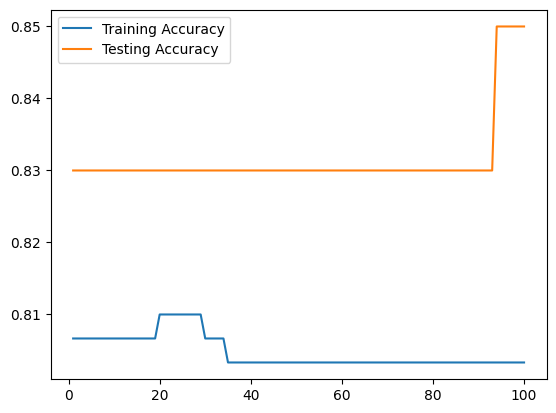

In [29]:
print("======== Classification performance ==============")
#분류 성능 측도
print(sklearn.metrics.accuracy_score(y_test, y_pred))
print(sklearn.metrics.f1_score(y_test, y_pred))
plt.plot([i for i in range(1, 101)], train_acc, label = "Training Accuracy")
plt.plot([i for i in range(1, 101)], test_acc, label = "Testing Accuracy")
plt.legend()
plt.savefig('train_test.png', dpi=300)  ## dpi 해상도
plt.show()

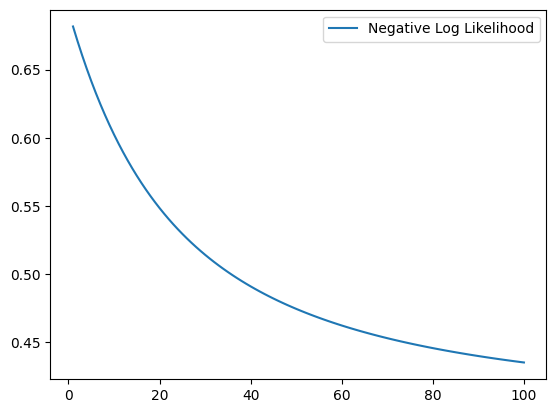

In [30]:
# Negative log likelihood 그림 
plt.plot([i for i in range(1, 101)], l, label = "Negative Log Likelihood")
plt.legend()
plt.savefig('Negative_log_likelihood.png', dpi=300)
plt.show()

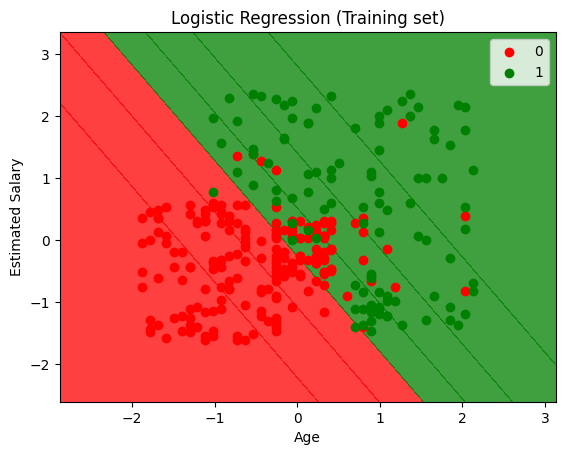

In [31]:
### 훈련 결과 가시화
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
##
##

predict = np.array([np.dot(x, w) for x in np.array([X1.ravel(), X2.ravel()]).T]).reshape(X1.shape)


plt.contourf(X1, X2, np.array([sigmoid(np.dot(x, w)) for x in np.array([X1.ravel(), X2.ravel()]).T]).reshape(X1.shape), alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

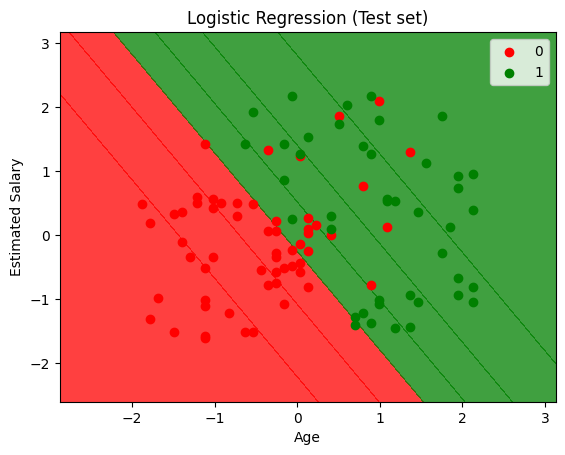

In [32]:
### 테스트결과 가시화
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, np.array([sigmoid(np.dot(x, w)) for x in np.array([X1.ravel(), X2.ravel()]).T]).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

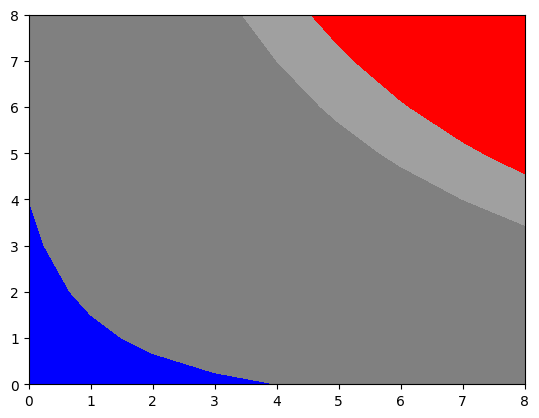

In [33]:
x = np.arange(1, 10)
y = x.reshape(-1, 1)
h = x * y

cs = plt.contourf(h, levels=[5, 40, 50],
    colors=['#808080', '#A0A0A0', '#C0C0C0'], extend='both')

## 컨투어에프 함수의 사용법에 대해서 예시를 들어주는 내용이다.
## https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html 참고하라.
cs.cmap.set_over('red')
cs.cmap.set_under('blue')
cs.changed()